In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

print("Imported")


Imported


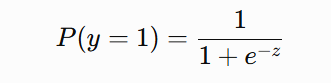

In [3]:
X = np.linspace(10,50,100) # Temperature to get headache
y = np.array([0]*70+[1]*30) # Headache or Ok

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)
count_1 = 0
for i in y_test:
    if i == 1:
        count_1 += 1
print(count_1,20/count_1)
#stratify=y -> keep the same rate between y and y train (0|1|30%)

#model_saga = LogisticRegression(solver='saga',max_iter=500,penalty='elasticnet',l1_ratio=0.5,random_state=42)
model_liblinear = LogisticRegression(solver='liblinear',max_iter=100,random_state=42)
#penalty="l1" -> Rounding the non-relevant features(like 0.25) to 0 with many features it is use-full.
#penalty="l2" -> Default. prevent over-learning while training the model.
#penalty="elasticnet" -> Combine the l1 and l2 features.
#solver="saga" -> Use-full for big project keep on growing flow and picking the most use-full updates.
#solver='liblinear' -> Good for basic size of dataset.
#max_iter=1000 -> the most time the training will last, max iter control the gathering time.
#class_weight="balanced" -> Use-full when the clas sizes is not balanced(cl0->50S,cl1->400S).
#tol=1e-4 -> Decide how far the parameters improving is un-necessary for the-continue.


# print('saga👇')
# model_saga.fit(X_train.reshape(-1,1), y_train)
# y_prediction_saga = model_saga.predict(X_test.reshape(-1,1))
# print(y_prediction_saga)
# print(f'{accuracy_score(y_test, y_prediction_saga)*100:.2f}%')


print("="*50,f'\n','\rliblinear👇')
model_liblinear.fit(X_train.reshape(-1,1), y_train)
y_prediction_lib = model_liblinear.predict(X_test.reshape(-1,1))

#we will work with liblinear.
b0 = model_liblinear.intercept_[0]
b1 = model_liblinear.coef_[0][0]

print('intercept: ',b0)
print('coefficient: ',b1)

cm = confusion_matrix(y_test, y_prediction_lib)
print(cm)
tn = cm[0,0]
fp = cm[0,1]
fn = cm[1,0]
tp = cm[1,1]

accuracy = (tp+tn) / (tp+tn+fp+fn)
print(f'Model Accuracy: ',f'{accuracy*100:.2f}%')
#print(f'\nModel acc: ',f'{accuracy_score(y,y_prediction)*100:.2f}%')
#both accuracy same

6 3.3333333333333335
liblinear👇
intercept:  -4.037601383052556
coefficient:  0.10706543660572393
[[14  0]
 [ 0  6]]
Model Accuracy:  100.00%


Decision boundry:  37.711529612692004


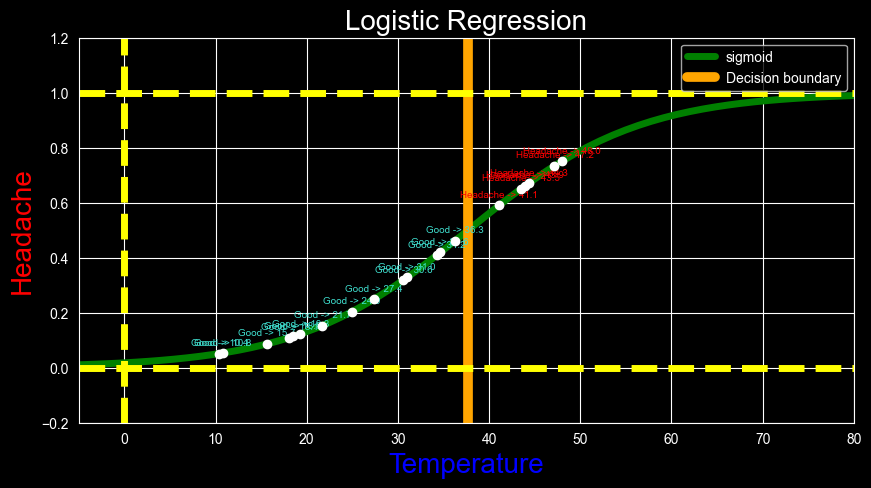

In [4]:
#p(y=1)=1/(1+(e^-f(x))) = 0.5   -> Decision Boundary
#0.5*(1+(e^-f(x))) = 1  \0.5
#1+(e^-f(x)) = 2
#e^-f(x) = 1
#e^-(?)  == 1  -> 0
#-f(x) = 0
#f(x) = b0+b1*x = 0    -b0
#-b0 = b1*x
# x = -b0 / b1                 -> Decision Boundary
decision_boundary = -b0 / b1
print(f'Decision boundry: ', decision_boundary)

x = np.linspace(-20,120,100)
y_sigmoid = 1/(1+np.exp(-(b1*x+b0)))

#sigmoid the y test
y_test_sigmoid = 1/(1+np.exp(-(b1*X_test+b0)))


fig, axes = plt.subplots(figsize=(10,5))


axes.plot(x.reshape(-1,1),y_sigmoid,color='green',linewidth = 5,label='sigmoid')
axes.set_title('Logistic Regression',fontsize=20)

#x and y labels
axes.set_xlabel('Temperature',color='blue',fontsize=20)
axes.set_ylabel('Headache',color='red',fontsize=20)

#decision boundary line
axes.axvline(decision_boundary,color='orange',linewidth=7,label='Decision boundary')

#x and y lines
axes.axvline(0,linestyle='--',color='yellow',linewidth=5)
axes.axhline(0,linestyle='--',color='yellow',linewidth=5)

#edge marker
axes.axhline(1,linestyle='--',color='yellow',linewidth=5)

axes.set_xlim(-5,80)
axes.set_ylim(-0.2,1.2)

for i in range(len(X_test)):
    plt.scatter(X_test[i],y_test_sigmoid[i],color="white",zorder = 5)
    plt.annotate(f'Headache -> {X_test[i]:.1f}' if X_test[i] > decision_boundary else f'Good -> {X_test[i]:.1f}',(X_test[i],y_test_sigmoid[i]),textcoords='offset points',xytext=(0,6),ha='center',fontsize=7,color='red' if X_test[i] > decision_boundary else 'turquoise')

plt.legend()
plt.show()